In [1]:
import os

print(os.getcwd())

C:\Users\91880


In [2]:
import pandas as pd
import json
from itertools import islice
from sqlalchemy import create_engine
import sqlite3

In [3]:
with open(r"H:\Yelp_data\yelp_academic_dataset_business.json",
          'r',
          encoding='utf-8') as f:

    business_data = [json.loads(line) for line in islice(f, 50000)]

business_df = pd.DataFrame(business_data)

print("Business Dataset Shape:", business_df.shape)

Business Dataset Shape: (50000, 14)


In [4]:
with open(r"H:\Yelp_data\yelp_academic_dataset_checkin.json",
          'r',
          encoding='utf-8') as f:

    checkin_data = [json.loads(line) for line in islice(f, 50000)]

checkin_df = pd.DataFrame(checkin_data)

print("Checkin Dataset Shape:", checkin_df.shape)

Checkin Dataset Shape: (50000, 2)


In [5]:
with open(r"H:\Yelp_data\yelp_academic_dataset_review.json",
          'r',
          encoding='utf-8') as f:

    review_data = [json.loads(line) for line in islice(f, 50000)]

review_df = pd.DataFrame(review_data)

print("Review Dataset Shape:", review_df.shape)

Review Dataset Shape: (50000, 9)


In [6]:
with open(r"H:\Yelp_data\yelp_academic_dataset_tip.json",
          'r',
          encoding='utf-8') as f:

    tip_data = [json.loads(line) for line in islice(f, 50000)]

tip_df = pd.DataFrame(tip_data)

print("Tip Dataset Shape:", tip_df.shape)

Tip Dataset Shape: (50000, 5)


In [7]:
with open(r"H:\Yelp_data\yelp_academic_dataset_user.json",
          'r',
          encoding='utf-8') as f:

    user_data = [json.loads(line) for line in islice(f, 50000)]

user_df = pd.DataFrame(user_data)

print("User Dataset Shape:", user_df.shape)

User Dataset Shape: (50000, 22)


In [8]:
business_df.drop(['attributes', 'hours'],
                 axis=1,
                 inplace=True,
                 errors='ignore')

In [9]:
business_df = business_df.astype(str)
review_df = review_df.astype(str)
user_df = user_df.astype(str)
tip_df = tip_df.astype(str)
checkin_df = checkin_df.astype(str)

In [10]:
engine = create_engine('sqlite:///yelp.db')

In [11]:
def load_dataframe(df, table_name, engine):

    df.to_sql(table_name,
              con=engine,
              if_exists='replace',
              index=False)

In [12]:
load_dataframe(business_df, 'business', engine)

load_dataframe(review_df, 'review', engine)

load_dataframe(user_df, 'user', engine)

load_dataframe(tip_df, 'tip', engine)

load_dataframe(checkin_df, 'checkin', engine)

print("Database Created Successfully!")

Database Created Successfully!


# Problem Statement

### In a competitive market like the restaurant industry, understanding the factors that influence business success is crucial for stakeholders. Utilizing the Yelp dataset, this project aims to investigate the relationship between user engagement (reviews, tips, and check-ins) and business success metrics (review count, ratings) for restaurants.

# Research Objectives
### 1. Quantify the correlation between user engagement (reviews, tips, check-ins) and review count/average star rating:

### This will help us determine if restaurants with higher user engagement experience a corresponding increase in reviews and ratings.
 
### 2. Analyze the impact of sentiment on review count and average star rating:

### We will investigate if positive sentiment in reviews and tips translates to higher star ratings and potentially influences the total number of reviews left.

### 3. Time trends in User Engagement:

### We will explore if consistent user engagement over time is a stronger indicator of long-term success compared to sporadic bursts of activity.

# Hypothesis Testing
### Higher levels of user engagement (more reviews, tips, and check-ins) correlate with higher review counts and ratings for restaurants.
### Positive sentiment expressed in reviews and tips contributes to higher overall ratings and review counts for restaurants.
### Consistent engagement over time is positively associated with sustained business success for restaurants.

In [13]:
import pandas as pd                                          # Used for data manipulation and DataFrame operations
import numpy as np                                           # Used for numerical computations and arrays
import matplotlib.pyplot as plt                              # Used for creating charts and graphs
import seaborn as sns                                        # Used for advanced statistical data visualizations
from datetime import datetime                                # Used for handling date and time data
import sqlite3                                               # Used for connecting and working with SQLite databases
import folium                                                # Used for creating interactive maps and location visualizations
from geopy.geocoders import Nominatim                        # Used for converting addresses into latitude and longitude coordinates (Geocoding)
from matplotlib.colors import LinearSegmentedColormap        # Used for creating custom color gradients in visualizations
from IPython.display import display                          # Used for displaying DataFrames, outputs, and visual objects properly in Jupyter Notebook.
import warnings                                              # Used for handling and controlling warning messages.



warnings.filterwarnings('ignore')                            # Used for hiding unnecessary warning messages from output

# Database Connection

In [14]:
conn = sqlite3.connect('yelp.db')

In [15]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn 
)

tables

,name
0,business
1,review
2,user
3,tip
4,checkin


In [16]:
# explore types of data available in tables
for table in tables ['name']:
    display(pd.read_sql_query(f"select * from {table} limit 5 ", conn))

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,categories
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.4266787,-119.7111968,5.0,7,0,"Doctors, Traditional Chinese Medicine, Naturop..."
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,"Shipping Centers, Local Services, Notaries, Ma..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"Department Stores, Shopping, Fashion, Home & G..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.9555052,-75.1555641,4.0,80,1,"Restaurants, Food, Bubble Tea, Coffee & Tea, B..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.3381827,-75.4716585,4.5,13,1,"Brewpubs, Breweries, Food"


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


,user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,"NSCy54eWehBJyZdG2iE84w, pe42u7DcCH2QmI81NX-8qA...",267,...,65,55,56,18,232,844,467,467,239,180
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...","ueRPE0CX75ePGMqOFVj6IQ, 52oH4DrRvzzl8wh5UXyU0A...",3138,...,264,184,157,251,1847,7054,3131,3131,1521,1946
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00,2086,1010,1003,"2009,2010,2011,2012,2013","LuO3Bn4f3rlhyHIaNfTlnA, j9B4XdHUhDfTKVecyWQgyA...",52,...,13,10,17,3,66,96,119,119,35,18
3,SZDeASXq7o05mMNLshsdIA,Gwen,224,2005-11-29 04:38:33,512,330,299,"2009,2010,2011","enx1vVPnfdNUdPho6PH_wg, 4wOcvMLtU6a9Lslggq74Vg...",28,...,4,1,6,2,12,16,26,26,10,9
4,hA5lMy-EnncsH4JoR-hFGQ,Karen,79,2007-01-05 19:40:59,29,15,7,,"PBK4q9KEEBHhFvSXCUirIw, 3FWPpM7KU1gXeOM_ZbYMbA...",1,...,1,0,0,0,1,1,0,0,0,0


,user_id,business_id,text,date,compliment_count
0,AGNUgVwnZUey3gcPCJ76iw,3uLgwr0qeCNMjKenHJwPGQ,Avengers time with the ladies.,2012-05-18 02:17:21,0
1,NBN4MgHP9D3cw--SnauTkA,QoezRbYQncpRqyrLH6Iqjg,They have lots of good deserts and tasty cuban...,2013-02-05 18:35:10,0
2,-copOvldyKh1qr-vzkDEvw,MYoRNLb5chwjQe3c_k37Gg,It's open even when you think it isn't,2013-08-18 00:56:08,0
3,FjMQVZjSqY8syIO-53KFKw,hV-bABTK-glh5wj31ps_Jw,Very decent fried chicken,2017-06-27 23:05:38,0
4,ld0AperBXk1h6UbqmM80zw,_uN0OudeJ3Zl_tf6nxg5ww,Appetizers.. platter special for lunch,2012-10-06 19:43:09,0


,business_id,date
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020..."
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011..."
2,--30_8IhuyMHbSOcNWd6DQ,"2013-06-14 23:29:17, 2014-08-13 23:20:22"
3,--7PUidqRWpRSpXebiyxTg,"2011-02-15 17:12:00, 2011-07-28 02:46:10, 2012..."
4,--7jw19RH9JKXgFohspgQw,"2014-04-21 20:42:11, 2014-04-28 21:04:46, 2014..."


## Data Analysis

In [17]:
pd.read_sql_query("select count(*) from business", conn)

,count(*)
0,50000


In [18]:
business_id = pd.read_sql_query("""select business_id, review_count from business where lower(categories) like '%restaurant%' and is_open = 1""", conn)

In [19]:
# What is the descriptive stats for review count and star rating for businesses?
# avg, min, max, median

pd.read_sql_query(f"""SELECT

AVG(review_count) AS average_review_count,
MIN(review_count) AS min_review_count,
MAX(review_count) AS max_review_count,

(SELECT review_count 
 FROM business 
 ORDER BY review_count 
 LIMIT 1 OFFSET (SELECT COUNT(*) FROM business) / 2) 
 AS median_review_count,

AVG(stars) AS average_star_rating,
MIN(stars) AS min_star_rating,
MAX(stars) AS max_star_rating,

(SELECT stars 
 FROM business 
 ORDER BY stars 
 LIMIT 1 OFFSET (SELECT COUNT(*) FROM business) / 2) 
 AS median_star_rating

FROM business

WHERE business_id IN {tuple(business_id['business_id'])};

""", conn)

,average_review_count,min_review_count,max_review_count,median_review_count,average_star_rating,min_star_rating,max_star_rating,median_star_rating
0,106.62645,10,997,38,3.530764,1.0,5.0,3.5


In [20]:
# Function to remove outliers using IQR method
def remove_outliers(df, col):

    q1 = df[col].quantile(0.25)                                     # Calculate first quartile (25%)
    q3 = df[col].quantile(0.75)                                     # Calculate third quartile (75%)
    iqr = q3 - q1                                                   # Calculate Interquartile Range
    lower_bound = q1 - 1.5 * iqr                                    # Calculate lower limit
    upper_bound = q3 + 1.5 * iqr                                    # Calculate upper limit
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]    # Keep only values within bounds
    return df                                                       # Return cleaned dataframe

In [21]:
# Convert review_count column into numeric datatype

business_id['review_count'] = pd.to_numeric(
    business_id['review_count']
)

In [22]:
# Remove outliers from review_count column

business_id = remove_outliers(business_id, 'review_count')

In [23]:
business_id.shape

(10480, 2)

In [24]:
# Which restaurants have the highest number of reviews?

pd.read_sql_query(f"""
select name,
       sum(review_count) as review_count,
       avg(stars) as avg_rating

from business

where business_id in {tuple(business_id['business_id'])}

group by name

order by review_count desc

limit 10
""", conn)

,name,review_count,avg_rating
0,McDonald's,5580,1.812796
1,Chipotle Mexican Grill,3417,2.480769
2,Taco Bell,2633,2.116379
3,Buffalo Wild Wings,2592,2.354167
4,Chick-fil-A,2496,3.500000
5,Panera Bread,2205,2.644737
6,Texas Roadhouse,2125,3.400000
7,Applebee's Grill + Bar,1964,2.527778
8,First Watch,1901,4.033333
9,Olive Garden Italian Restaurant,1882,3.029412


In [25]:
# Which restaurants have the highest rating?

pd.read_sql_query(f"""
select name,
       sum(review_count) as review_count,
       avg(stars) as avg_rating

from business

where business_id in {tuple(business_id['business_id'])}

group by name

order by avg_rating desc

limit 10
""", conn)

,name,review_count,avg_rating
0,the brewers cabinet production,13,5.0
1,cabbage vegetarian cafe,12,5.0
2,agua bistro,25,5.0
3,Zlatne Kapi,11,5.0
4,Yinzer’s Amazing Cheesesteaks,24,5.0
5,Yellow Bicycle Canteen,13,5.0
6,Wolly’s Kitchen,10,5.0
7,Williamsburg Cucina Caffe' e Bottega,14,5.0
8,Whole and Grounded Cafe,16,5.0
9,"Westwood Grocery, Deli & Catering",9,5.0


In [26]:
# Do restaurants with higher engagement tend to have higher ratings?

pd.read_sql_query("""
select business_id,

sum(length(date) - length(replace(date, ',', '')) + 1) 
as checkin_count

from checkin

group by business_id
""", conn)

,business_id,checkin_count
0,---kPU91CF4Lq2-WlRu9Lw,11
1,--0iUa4sNDFiZFrAdIWhZQ,10
2,--30_8IhuyMHbSOcNWd6DQ,2
3,--7PUidqRWpRSpXebiyxTg,10
4,--7jw19RH9JKXgFohspgQw,26
...,...,...
49995,NJaR_2hke7NNAC6l1Ohr8g,716
49996,NJcoVbVwnYigsQVDOgl29Q,29
49997,NJe5fkia_63rdKXRdJlmkA,141
49998,NJg2ookzRGD2Ej-VNpuY-w,124


In [27]:
pd.read_sql_query("""
select business_id,
       count(*) as tip_count

from tip

group by business_id
""", conn)

,business_id,tip_count
0,--0iUa4sNDFiZFrAdIWhZQ,1
1,--7PUidqRWpRSpXebiyxTg,1
2,--8IbOsAAxjKRoYsBFL-PA,1
3,--MbOh2O1pATkXa7xbU6LA,1
4,--O3ip9NpXTKD4oBS1pY2A,1
...,...,...
25420,zyPz0xvE5XkeCVH2J7g2gw,1
25421,zyRXfBnoE1JZVN4SE7OaaA,1
25422,zz3E7kmJI2r2JseE6LAnrw,1
25423,zzIF9qp2UoHN48EeZH_IDg,1


In [28]:
review_count_df = pd.read_sql_query(f"""
SELECT total.avg_rating as rating,

AVG(total.review_count) as avg_review_count,

AVG(total.checkin_count) as avg_checkin_count,

AVG(total.tip_count) as avg_tip_count

FROM

(
    SELECT
        b.business_id,

        SUM(b.review_count) AS review_count,

        AVG(b.stars) AS avg_rating,

        SUM(LENGTH(cc.date) - LENGTH(REPLACE(cc.date, ',', '')) + 1)
        AS checkin_count,

        SUM(tip.tip_count) as tip_count

    FROM
        business b

    LEFT JOIN
        checkin cc
        ON b.business_id = cc.business_id

    LEFT JOIN
        (
            SELECT business_id,
                   COUNT(business_id) as tip_count
            FROM tip
            GROUP BY business_id
            ORDER BY tip_count
        ) as tip

        ON b.business_id = tip.business_id

    WHERE b.business_id IN {tuple(business_id['business_id'])}

    GROUP BY
        b.business_id

) as total

GROUP BY total.avg_rating

""", conn)

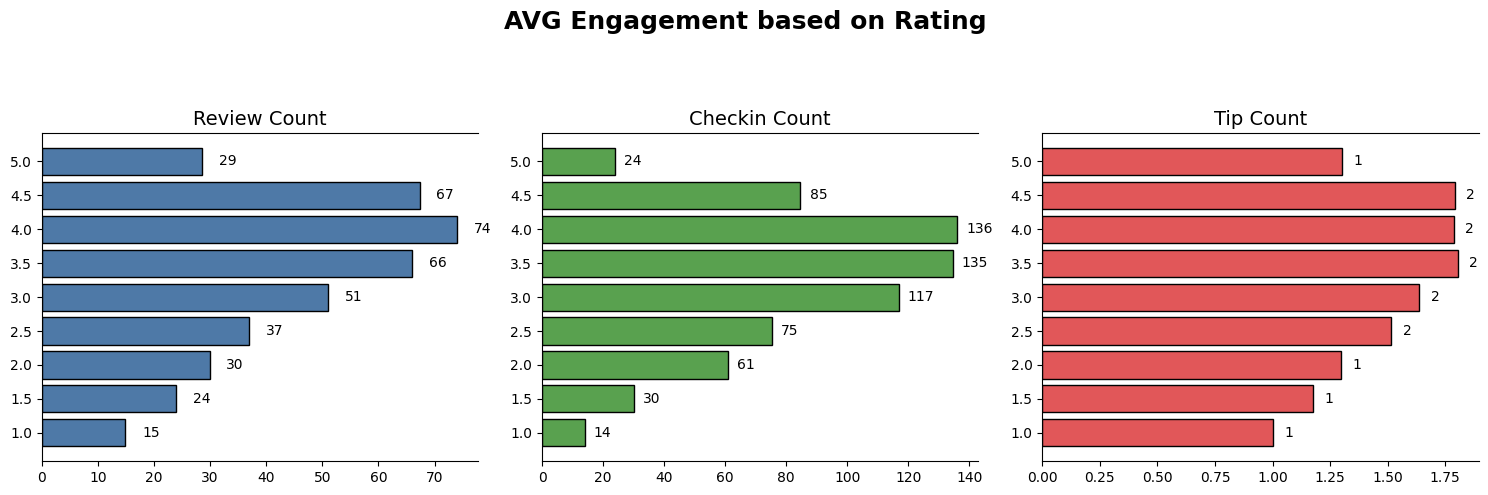

In [29]:
# ===================== AVG ENGAGEMENT BASED ON RATING ===================== #

plt.figure(figsize=(15,5))   # Create figure size

plt.suptitle('AVG Engagement based on Rating\n\n',
             fontsize = 18,
             fontweight = 'bold')

# ===================== GRAPH 1 : REVIEW COUNT ===================== #

plt.subplot(1,3,1)   # Create subplot (1 row, 3 columns, graph 1)

plt.title('Review Count', fontsize = 14)

plt.barh(
    review_count_df['rating'].astype('str'),
    review_count_df['avg_review_count'],
    
    edgecolor = 'black',
    color = '#4E79A7'      # BLUE COLOR
)

plt.gca().spines['right'].set_visible(False)

for i, value in enumerate(review_count_df['avg_review_count']):
    
    plt.text(
        value + 3,
        i,
        str(round(value)),
        color = 'black',
        va = 'center'
    )



# ===================== GRAPH 2 : CHECKIN COUNT ===================== #

plt.subplot(1,3,2)   # Create subplot (graph 2)

plt.title('Checkin Count', fontsize = 14)

plt.barh(
    review_count_df['rating'].astype('str'),
    review_count_df['avg_checkin_count'],
    
    edgecolor = 'black',
    color = '#59A14F'      # GREEN COLOR
)

plt.gca().spines['right'].set_visible(False)

for i, value in enumerate(review_count_df['avg_checkin_count']):
    
    plt.text(
        value + 3,
        i,
        str(round(value)),
        color = 'black',
        va = 'center'
    )



# ===================== GRAPH 3 : TIP COUNT ===================== #

plt.subplot(1,3,3)   # Create subplot (graph 3)

plt.title('Tip Count', fontsize = 14)

plt.barh(
    review_count_df['rating'].astype('str'),
    review_count_df['avg_tip_count'],
    
    edgecolor = 'black',
    color = '#E15759'      # RED COLOR
)

plt.gca().spines['right'].set_visible(False)

for i, value in enumerate(review_count_df['avg_tip_count']):
    
    plt.text(
        value + 0.05,
        i,
        str(round(value)),
        color = 'black',
        va = 'center'
    )

plt.tight_layout()   # Adjust spacing
plt.show()           # Display graphs

In [30]:
engagement_df = pd.read_sql_query(f"""

SELECT                                  -- Select required columns

    b.business_id,                      -- Business unique ID

    SUM(b.review_count) AS review_count,      -- Total review count

    AVG(b.stars) AS avg_rating,               -- Average star rating

    SUM(
        LENGTH(cc.date) -
        LENGTH(REPLACE(cc.date , ',' , '')) + 1
    ) AS checkin_count,                 -- Calculate check-in count

    SUM(tip.tip_count) AS tip_count,    -- Total tip count
     (
        CASE                                                         -- Create rating category

            WHEN b.stars >= 3.5 THEN 'High-Rated'                    -- Rating greater than 3.5

            ELSE 'Low-Rated'                                         -- Rating lower than 3.5

        END

    ) AS category                                                    -- Category column



FROM
    business b                          -- Main business table


LEFT JOIN
    checkin cc

ON b.business_id = cc.business_id       -- Match business IDs


LEFT JOIN
(
    SELECT

        business_id,                    -- Select business ID

        COUNT(business_id) AS tip_count -- Count total tips

    FROM tip

    GROUP BY business_id                -- Group by business

    ORDER BY tip_count                  -- Sort by tip count

) AS tip


ON b.business_id = tip.business_id      -- Join tip table


WHERE b.business_id IN

{tuple(business_id['business_id'])}     -- Filter selected businesses


GROUP BY
    b.business_id                       -- Group final output

""", conn).dropna()

In [31]:
engagement_df[['review_count','checkin_count','tip_count']].corr()

,review_count,checkin_count,tip_count
review_count,1.000000,0.581949,0.388823
checkin_count,0.581949,1.000000,0.443906
tip_count,0.388823,0.443906,1.000000


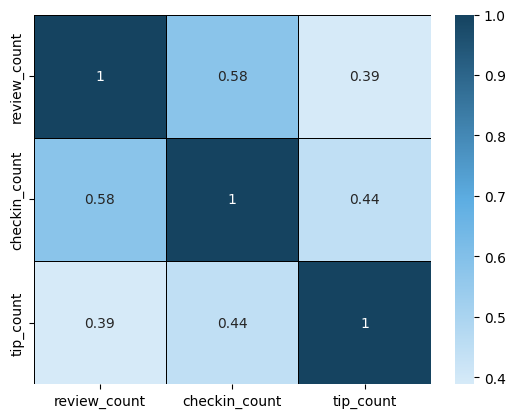

In [32]:
# Define custom colors for heatmap
colors = ['#D6EAF8', '#5DADE2', '#154360']

# Create custom color map
custom_cmap = LinearSegmentedColormap.from_list(
    "mycmap",
    colors
)

# Create heatmap
sns.heatmap(

    engagement_df[
        ['review_count', 'checkin_count', 'tip_count']
    ].corr(),

    cmap = custom_cmap,      # Apply new blue color theme

    annot = True,            # Show values inside boxes

    linewidths = 0.5,        # Border width

    linecolor = 'black'      # Border color

)

# Display graph
plt.show()

In [33]:
# ================= HIGH VS LOW RATED BUSINESS ENGAGEMENT ================= #

engagement_df.groupby("category")[['review_count','tip_count','checkin_count']].mean()

,review_count,tip_count,checkin_count
category,,,
High-Rated,109.460389,1.762332,258.877429
Low-Rated,71.042813,1.394495,186.275229


In [60]:
from scipy import stats

# ================= HYPOTHESIS TESTING: ENGAGEMENT vs RATING CATEGORY ================= #
# H0 (Null): High-Rated aur Low-Rated restaurants ke beech engagement mein koi significant difference nahi hai
# H1 (Alternative): High-Rated restaurants ka engagement significantly different hai Low-Rated se

high_rated = engagement_df[engagement_df['category'] == 'High-Rated']
low_rated = engagement_df[engagement_df['category'] == 'Low-Rated']

metrics = ['review_count', 'tip_count', 'checkin_count']

print("Hypothesis Testing Results (Independent T-Test):\n")
for metric in metrics:
    t_stat, p_value = stats.ttest_ind(
        high_rated[metric].dropna(), 
        low_rated[metric].dropna(), 
        equal_var=False  # Welch's t-test - safer jab variance equal na ho
    )
    
    significance = "Significant " if p_value < 0.05 else "Not Significant "
    
    print(f"{metric}:")
    print(f"  T-statistic: {t_stat:.3f}")
    print(f"  P-value: {p_value:.5f}")
    print(f"  Result: {significance} (at α=0.05)\n")

Hypothesis Testing Results (Independent T-Test):

review_count:
  T-statistic: 9.399
  P-value: 0.00000
  Result: Significant  (at α=0.05)

tip_count:
  T-statistic: 5.665
  P-value: 0.00000
  Result: Significant  (at α=0.05)

checkin_count:
  T-statistic: 4.800
  P-value: 0.00000
  Result: Significant  (at α=0.05)



## Hypothesis Testing: Rating Category vs Engagement

**Objective:** Test whether High-Rated and Low-Rated restaurants show 
statistically significant differences in customer engagement metrics.

**Method:** Independent two-sample t-test (Welch's, unequal variance assumed)

**Findings:** All three engagement metrics showed statistically significant differences 
between High-Rated and Low-Rated restaurants (p < 0.001).
High-Rated restaurants had notably higher review counts (109.46 vs 71.04),
check-ins (258.88 vs 186.28), and tips (1.76 vs 1.39).

In [35]:
# ================= SUCCESS SCORE FUNCTION ================= #
# Calculate restaurant success score using average rating and review count

def calculate_success_metric(df):

    success_score = []                         # Create empty list to store success scores

    for index, row in df.iterrows():          # Loop through each dataframe row

        score = row['avg_rating'] * np.log(row['review_count'] + 1)
        # Formula for calculating success score

        success_score.append(score)           # Store score inside list

    return success_score                      # Return final success score list

In [36]:
# ================= CITY & STATE SUCCESS ANALYSIS ================= #
# Analyze restaurant performance across different cities and states

city_df = pd.read_sql_query(f"""

SELECT city,state,latitude,longitude,
       AVG(stars) AS avg_rating,                 -- Average restaurant rating
       SUM(review_count) AS review_count,        -- Total review count
       COUNT(*) AS restaurant_count              -- Total restaurants

FROM business

WHERE
    business_id IN {tuple(business_id['business_id'])}
    -- Filter restaurant businesses


GROUP BY
    state, city 
    ORDER BY
    review_count DESC
    LIMIT 10""", conn)

city_df['success_score'] = calculate_success_metric(city_df)

In [37]:
# Convert latitude, longitude, and success_score columns into numeric datatype for mathematical calculations

# Remove missing (NaN) values generated during datatype conversion to avoid errors in map visualization

city_df['latitude'] = pd.to_numeric(city_df['latitude'], errors='coerce')   # Convert latitude into numeric

city_df['longitude'] = pd.to_numeric(city_df['longitude'], errors='coerce') # Convert longitude into numeric

city_df['success_score'] = pd.to_numeric(city_df['success_score'], errors='coerce') # Convert success score into numeric

city_df = city_df.dropna()   # Remove null values after conversion

In [38]:
# ================== SUCCESS SCORE MAP VISUALIZATION ================== #

# This visualization displays restaurant success scores across different cities on an interactive map
# Marker colors represent performance levels based on the calculated success score

m = folium.Map(
    
    location=[city_df['latitude'].mean(), city_df['longitude'].mean()],  
    # Set the center position of the map using average latitude and longitude values
    # .mean() calculates the average coordinates of all cities
    # This helps place the map approximately at the center of all locations
    
    zoom_start=4  
    # Set initial zoom level of the map
    # Smaller value = more zoomed out
    # Larger value = more zoomed in
    
)

color_scale = folium.LinearColormap(
    
    colors=['green', 'yellow', '#E54F29'],  
    # Define color gradient for success score visualization
    # Green = low score
    # Yellow = medium score
    # Orange/Red = high score
    
    vmin=city_df['success_score'].min(),    
    # Minimum success score value
    # Used as starting point of color scale
    
    vmax=city_df['success_score'].max()     
    # Maximum success score value
    # Used as ending point of color scale
    
)

for index, row in city_df.iterrows():  
    
    # iterrows() loops through every row of dataframe one by one
    # index = row number
    # row = complete data of one city
    
    folium.CircleMarker(
        
        location=[row['latitude'], row['longitude']],  
        # Place marker using city latitude and longitude coordinates
        
        radius=5,                                      
        # Size of circular marker
        # Higher value creates larger circle
        
        color=color_scale(row['success_score']),       
        # Set border color according to success score
        # Higher success score gets darker/hotter color
        
        fill=True,                                     
        # Fill the circle marker with color
        
        fill_color=color_scale(row['success_score']),  
        # Set internal fill color using success score
        
        fill_opacity=0.7,                              
        # Control marker transparency
        # 0 = fully transparent
        # 1 = fully visible
        
        popup=f"Success Score: {row['success_score']}" 
        
        # Display popup message when marker is clicked
        # f-string dynamically inserts success score value
        
    ).add_to(m)                                        
    # Add each generated marker to the main map object

m.add_child(color_scale)  
# Add color scale legend bar to the map
# Helps users understand color meaning based on score

m  # Display final interactive map output

In [39]:
# ===================== USER ENGAGEMENT ANALYSIS OVER TIME ==================== #
# Analyze monthly review and tip engagement trends for high-rated and low-rated restaurants

high_rated_engagement = pd.read_sql_query(f"""

SELECT 
    
    review.month_year,                    -- Month and year
    
    review.review_count,                  -- Total reviews
    
    tip.tip_count                         -- Total tips

FROM

(
    SELECT 
        
        strftime('%m-%Y', date) AS month_year,   -- Convert date into month-year format
        
        COUNT(*) AS review_count                 -- Count total reviews
        
    FROM review
    
    WHERE business_id IN {tuple(business_id['business_id'])} 
        
        AND stars >= 3.5                         -- Filter high-rated businesses
        
    GROUP BY month_year                         -- Group data by month
    
    ORDER BY month_year
    
) AS review


JOIN

(
    SELECT 
        
        AVG(b.stars),                           -- Average business rating
        
        strftime('%m-%Y', tip.date) AS month_year,  -- Convert tip date into month-year
        
        COUNT(*) AS tip_count                   -- Count total tips
        
    FROM tip
    
    JOIN business AS b
    
    ON tip.business_id = b.business_id         -- Match business IDs
    
    WHERE tip.business_id IN {tuple(business_id['business_id'])}
    
        AND b.stars >= 3.5                     -- Filter high-rated businesses
        
    GROUP BY month_year
    
    ORDER BY month_year
    
) AS tip


ON review.month_year = tip.month_year          -- Match records using month-year

""", conn)



low_rated_engagement = pd.read_sql_query(f"""

SELECT 
    
    review.month_year,                    -- Month and year
    
    review.review_count,                  -- Total reviews
    
    tip.tip_count                         -- Total tips

FROM

(
    SELECT 
        
        strftime('%m-%Y', date) AS month_year,   -- Convert date into month-year format
        
        COUNT(*) AS review_count                 -- Count total reviews
        
    FROM review
    
    WHERE business_id IN {tuple(business_id['business_id'])}
    
        AND stars < 3.5                          -- Filter low-rated businesses
        
    GROUP BY month_year                         -- Group data by month
    
    ORDER BY month_year
    
) AS review


JOIN

(
    SELECT 
        
        AVG(b.stars),                           -- Average business rating
        
        strftime('%m-%Y', tip.date) AS month_year,  -- Convert tip date into month-year
        
        COUNT(*) AS tip_count                   -- Count total tips
        
    FROM tip
    
    JOIN business AS b
    
    ON tip.business_id = b.business_id         -- Match business IDs
    
    WHERE tip.business_id IN {tuple(business_id['business_id'])}
    
        AND b.stars < 3.5                      -- Filter low-rated businesses
        
    GROUP BY month_year
    
    ORDER BY month_year
    
) AS tip


ON review.month_year = tip.month_year          -- Match records using month-year

""", conn)

In [40]:
high_rated_engagement

,month_year,review_count,tip_count
0,01-2010,20,4
1,01-2011,25,30
2,01-2012,29,62
3,01-2013,43,2
4,01-2014,44,32
...,...,...,...
95,12-2013,62,64
96,12-2014,55,2
97,12-2015,96,10
98,12-2016,82,43


In [41]:
# ===================== RATING TREND ANALYSIS OVER TIME ==================== #
# Analyze how average restaurant ratings change month by month over time

time_rating = pd.read_sql_query(f"""

SELECT 
    
    strftime('%m-%Y', date) AS month_year,   -- Convert review date into month-year format
    
    AVG(stars) AS avg_rating                 -- Calculate average rating

FROM review

WHERE business_id IN {tuple(business_id['business_id'])}   -- Filter selected restaurant businesses

GROUP BY month_year                                        -- Group data month-wise

ORDER BY month_year                                        -- Sort data chronologically

""", conn)

In [42]:
time_rating

,month_year,avg_rating
0,01-2006,4.333333
1,01-2008,3.750000
2,01-2009,3.500000
3,01-2010,4.000000
4,01-2011,3.783784
...,...,...
127,12-2013,3.428571
128,12-2014,3.290000
129,12-2015,3.654930
130,12-2016,3.566929


In [43]:
# ===================== DATA CLEANING & DATE FORMATTING ==================== #
# Convert month_year column into datetime format for proper time-series analysis

time_rating['month_year'] = pd.to_datetime(time_rating['month_year'])  # Convert month_year into datetime datatype

time_rating.sort_values('month_year', inplace=True)  # Sort records chronologically by date

time_rating = time_rating[time_rating['month_year'] > '2017']  # Filter records after 2017


# ===================== HIGH-RATED BUSINESS ENGAGEMENT CLEANING ==================== #
# Prepare high-rated engagement dataset for trend analysis

high_rated_engagement['month_year'] = pd.to_datetime(high_rated_engagement['month_year'])  # Convert date column into datetime format

high_rated_engagement.sort_values('month_year', inplace=True)  # Sort data by month_year

high_rated_engagement = high_rated_engagement[high_rated_engagement['month_year'] > '2017']  # Keep data after 2017


# ===================== LOW-RATED BUSINESS ENGAGEMENT CLEANING ==================== #
# Prepare low-rated engagement dataset for comparison analysis

low_rated_engagement['month_year'] = pd.to_datetime(low_rated_engagement['month_year'])  # Convert date column into datetime format

low_rated_engagement.sort_values('month_year', inplace=True)  # Sort data chronologically

low_rated_engagement = low_rated_engagement[low_rated_engagement['month_year'] > '2017']  # Filter recent records only

In [44]:
# ===================== MERGE AVERAGE RATING DATA ==================== #
# Merge avg_rating column into high-rated engagement dataset using month_year

high_rated_engagement = pd.merge(
    
    high_rated_engagement,                 # Main dataframe
    
    time_rating[['month_year','avg_rating']],  # Select required columns
    
    on='month_year',                       # Match records using month_year
    
    how='left'                             # Keep all high-rated engagement records
)

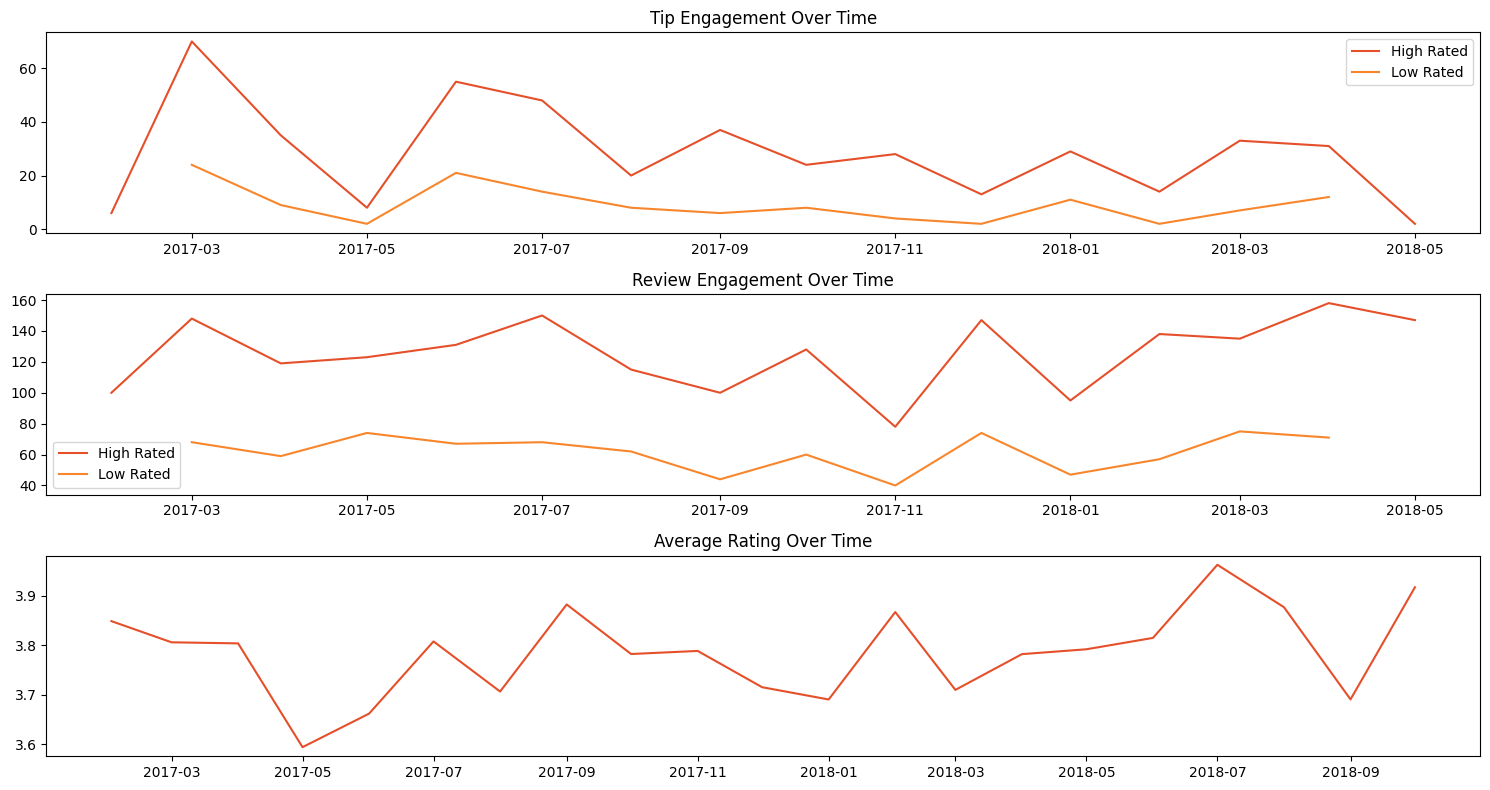

In [45]:
# ===================== USER ENGAGEMENT TREND VISUALIZATION ==================== #
# Visualize tip count, review count, and average rating trends over time

plt.figure(figsize=(15,8))   # Set overall figure size



# ===================== TIP ENGAGEMENT GRAPH ==================== #
# Compare tip engagement trends between high-rated and low-rated businesses

plt.subplot(3,1,1)   # Create first subplot

plt.title('Tip Engagement Over Time')   # Set graph title

plt.plot(
    high_rated_engagement['month_year'],   # X-axis values for high-rated businesses
    high_rated_engagement['tip_count'],    # Y-axis values for tip counts
    label='High Rated',                    # Label for legend
    color='#E54F29'                        # Line color
)

plt.plot(
    low_rated_engagement['month_year'],    # X-axis values for low-rated businesses
    low_rated_engagement['tip_count'],     # Y-axis values for tip counts
    label='Low Rated',                     # Label for legend
    color='#F8862C'                        # Line color
)

plt.legend()   # Display legend



# ===================== REVIEW ENGAGEMENT GRAPH ==================== #
# Compare review trends between high-rated and low-rated businesses

plt.subplot(3,1,2)   # Create second subplot

plt.title('Review Engagement Over Time')   # Set graph title

plt.plot(
    high_rated_engagement['month_year'],      # X-axis values
    high_rated_engagement['review_count'],    # Y-axis review count
    label='High Rated',                       # Legend label
    color='#E54F29'                           # Line color
)

plt.plot(
    low_rated_engagement['month_year'],       # X-axis values
    low_rated_engagement['review_count'],     # Y-axis review count
    label='Low Rated',                        # Legend label
    color='#F8862C'                           # Line color
)

plt.legend()   # Show legend



# ===================== AVERAGE RATING TREND GRAPH ==================== #
# Display average restaurant rating trend over time

plt.subplot(3,1,3)   # Create third subplot

plt.title('Average Rating Over Time')   # Set graph title

plt.plot(
    time_rating['month_year'],   # X-axis month-year
    time_rating['avg_rating'],   # Y-axis average rating
    color='#E54F29'              # Line color
)

plt.tight_layout()   # Adjust spacing between plots

plt.show()   # Display all graphs

In [46]:
# ===================== TIME SERIES DATA PREPARATION ==================== #
# Prepare datasets for seasonal trend analysis using month_year as index

tip_high_rated = high_rated_engagement[
    ['month_year', 'tip_count']
].set_index('month_year')  
# Create time-series dataframe for tip engagement


review_high_rated = high_rated_engagement[
    ['month_year', 'review_count']
].set_index('month_year')  
# Create time-series dataframe for review engagement


rating_df = time_rating[
    ['month_year', 'avg_rating']
].set_index('month_year')  
# Create time-series dataframe for average rating

In [47]:
import sys

!{sys.executable} -m pip install statsmodels


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\91880\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


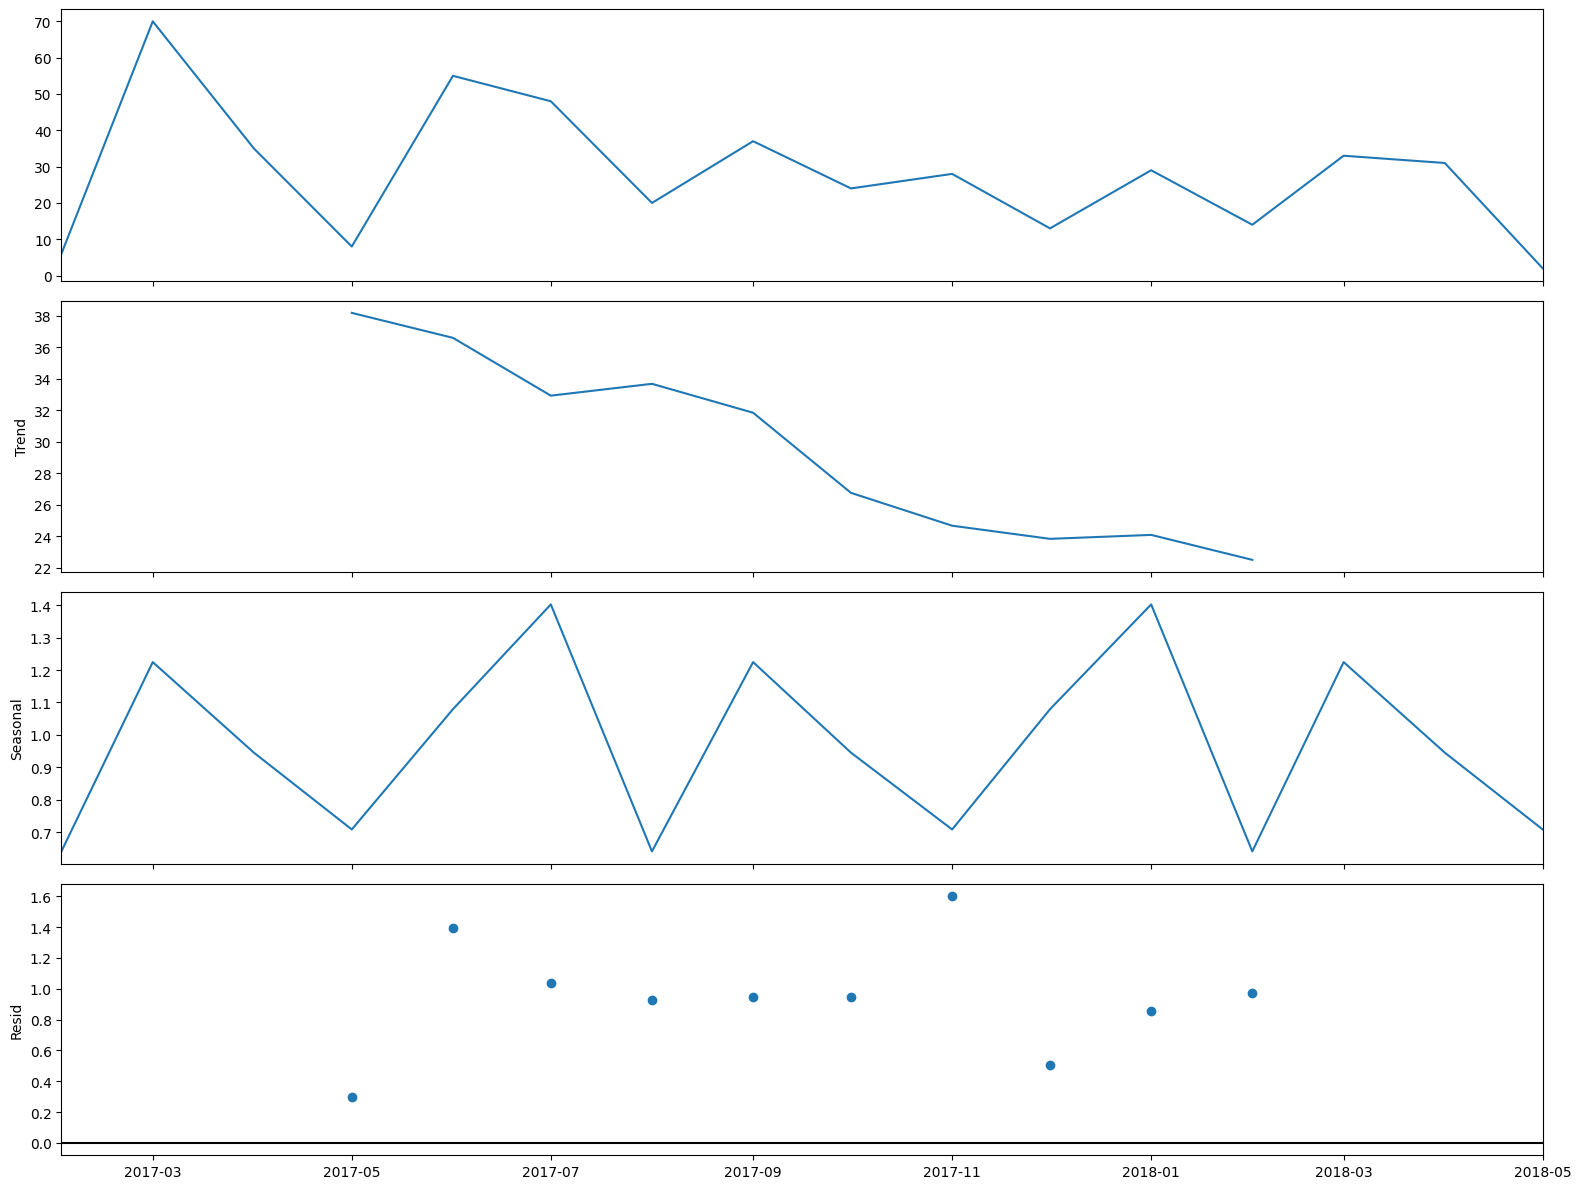

In [48]:
# ===================== SEASONAL DECOMPOSITION ANALYSIS ==================== #
# Analyze trend, seasonality, and residual patterns in tip engagement

from statsmodels.tsa.seasonal import seasonal_decompose  
# Import seasonal decomposition function

multiplicative_decomposition = seasonal_decompose(

    tip_high_rated,             # Input time-series dataset
    
    model='multiplicative',     # Use multiplicative decomposition model
    
    period=6                    # Define yearly seasonality (6 months)
)

plt.rcParams.update({
    
    'figure.figsize': (16,12)   # Set overall figure size
})

multiplicative_decomposition.plot()  
# Plot decomposition components

plt.show()  
# Display final visualization

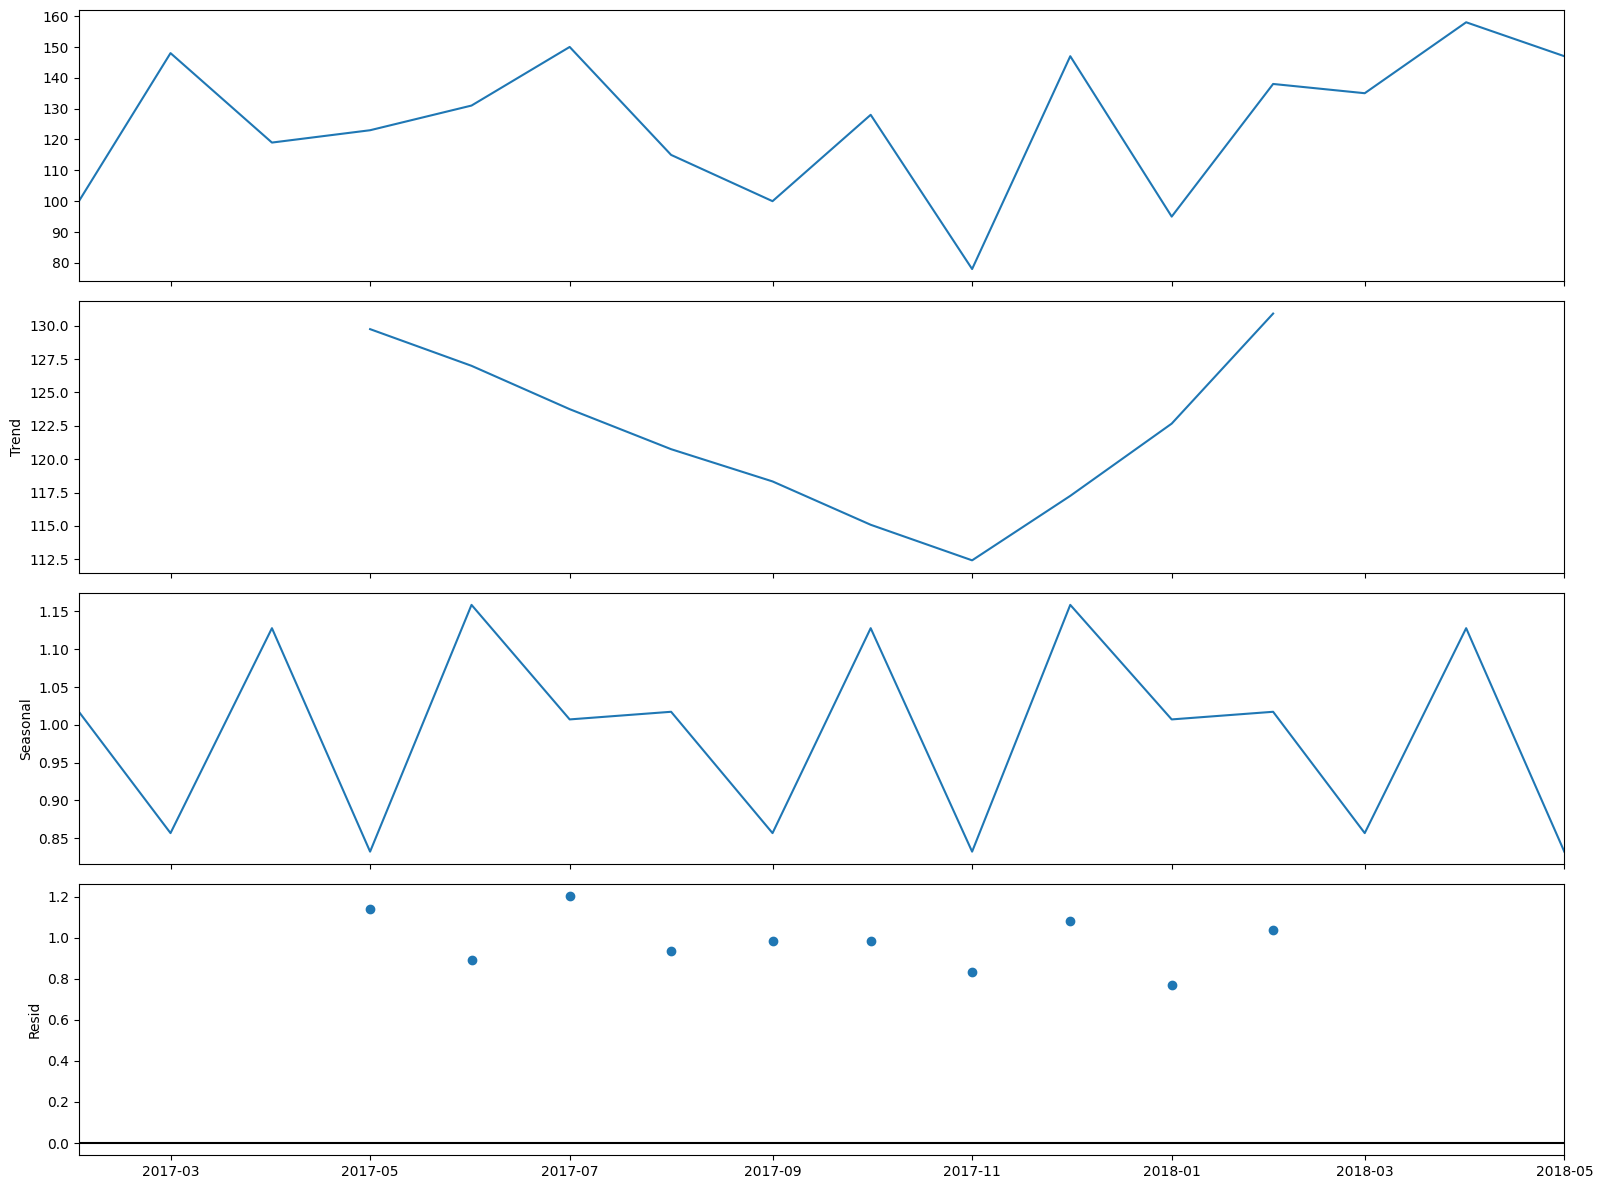

In [49]:
# ===================== SEASONAL DECOMPOSITION ANALYSIS ==================== #
# Analyze trend, seasonality, and residual patterns in tip engagement

from statsmodels.tsa.seasonal import seasonal_decompose  
# Import seasonal decomposition function

multiplicative_decomposition = seasonal_decompose(

    review_high_rated,             # Input time-series dataset
    
    model='multiplicative',     # Use multiplicative decomposition model
    
    period=6                    # Define yearly seasonality (6 months)
)

plt.rcParams.update({
    
    'figure.figsize': (16,12)   # Set overall figure size
})

multiplicative_decomposition.plot()  
# Plot decomposition components

plt.show()  
# Display final visualization

#### How does the sentiment of reviews and tips (useful, funny, cool) correlate with the success metrics of restaurants?
#### Analyze whether customer engagement reactions are related to restaurant ratings and popularity.

In [50]:
# ===================== REVIEW SENTIMENT & SUCCESS METRICS ANALYSIS ==================== #
# Analyze how useful, funny, and cool reviews correlate with restaurant success
sentiment_df = pd.read_sql_query(f"""

SELECT
    b.business_id,                                 -- Business unique ID
    AVG(b.stars) AS avg_rating,                    -- Average restaurant rating
    SUM(b.review_count) AS review_count,           -- Total review count
    SUM(s.useful_count) AS useful_count,           -- Total useful votes
    SUM(s.funny_count) AS funny_count,             -- Total funny votes
    SUM(s.cool_count) AS cool_count                -- Total cool votes
FROM
(
    SELECT
        business_id,                               -- Business ID from review table
        SUM(useful) AS useful_count,               -- Sum of useful reactions
        SUM(funny) AS funny_count,                 -- Sum of funny reactions
        SUM(cool) AS cool_count                    -- Sum of cool reactions
    FROM review
    GROUP BY business_id                           -- Group review sentiments by business
) AS s
JOIN business AS b
ON b.business_id = s.business_id                   -- Match business IDs
WHERE b.business_id IN
{tuple(business_id['business_id'])}                -- Filter selected restaurants
GROUP BY b.business_id                             -- Group final output
ORDER BY review_count                              -- Sort by review count
""", conn)
sentiment_df = remove_outliers(sentiment_df, 'review_count')   # Remove extreme values from review count
sentiment_df = remove_outliers(sentiment_df, 'useful_count')   # Remove outliers from useful reactions
sentiment_df = remove_outliers(sentiment_df, 'funny_count')    # Remove outliers from funny reactions
sentiment_df = remove_outliers(sentiment_df, 'cool_count')     # Remove outliers from cool reactions
display(sentiment_df)

,business_id,avg_rating,review_count,useful_count,funny_count,cool_count
0,2lyAf-llO6T_TMJKmg2NeA,2.0,5,0,0,0
1,3B9vzbshfvEMu_4HZnXmLQ,2.5,5,0,0,0
2,3nbvqLJwuwNn2gymccn5Xg,5.0,5,3,1,1
3,DNA6jRC6wt0QXO4zN-BdXw,2.0,5,3,0,0
4,J-qcPBEgIPhxvx-Uj4ahNQ,5.0,5,2,0,2
...,...,...,...,...,...,...
1872,aAdGIK9ewmiWtGzIcrQgNA,3.5,214,0,0,1
1873,g10CUV0LY50kLHMn5wgS_g,3.5,214,1,0,1
1879,Jx2AoB_IQOUrZ3s6fdAUSA,4.5,219,7,1,2
1889,1ddqdY_piKp-abaZ-bGRSA,3.5,226,10,1,1


In [51]:
# Calculate restaurant success score using sentiment dataset

sentiment_df['success_score'] = calculate_success_metric(sentiment_df)

# Add calculated success score column into dataframe

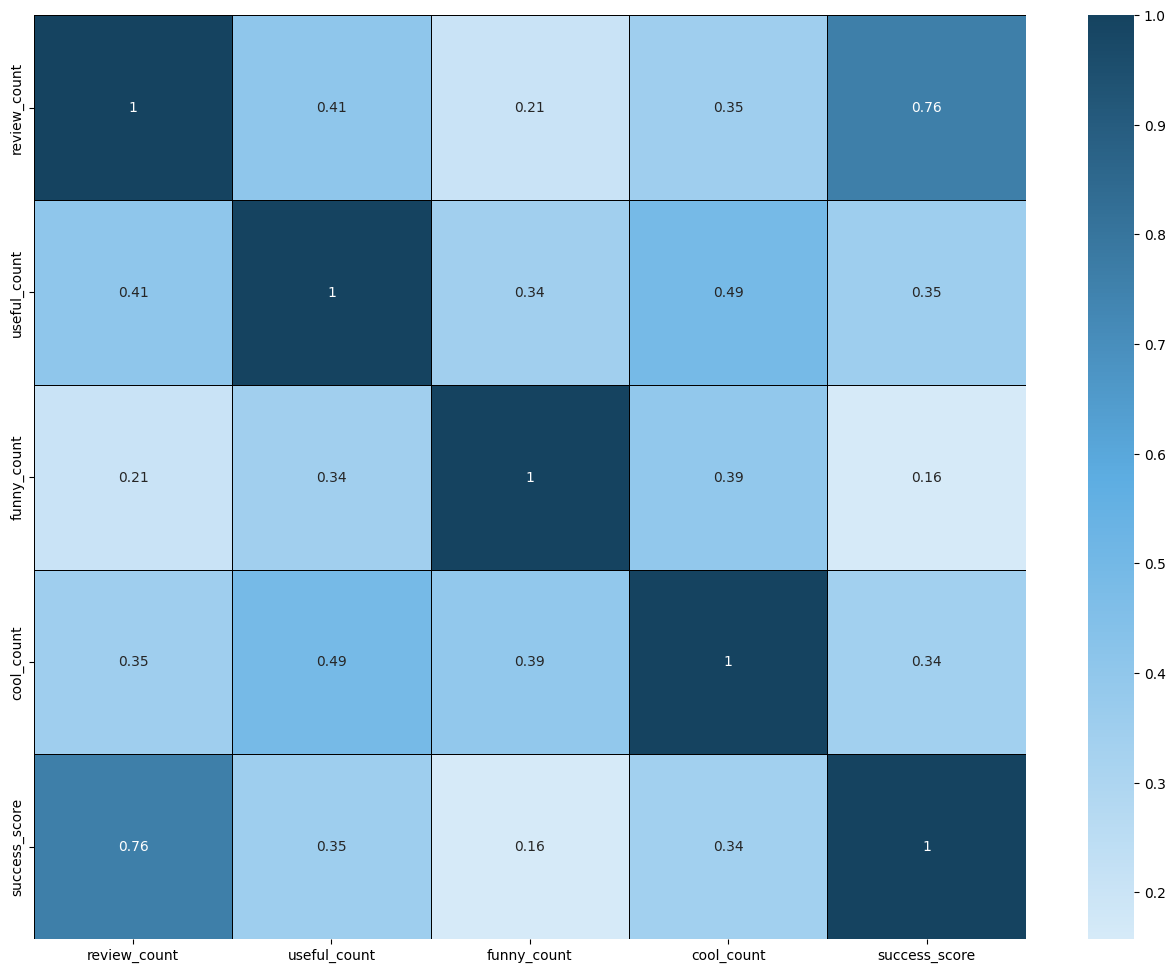

In [52]:
# Create correlation heatmap for sentiment and success metrics

sns.heatmap(
    
    sentiment_df.iloc[:,2:].corr(),      # Calculate correlation between numeric columns
    
    cmap = custom_cmap,                  # Apply custom color palette
    
    annot = True,                        # Display correlation values inside heatmap
    
    linewidths = 0.5,                   # Add border width between cells
    
    linecolor = 'black'                 # Set border color
    
)

plt.show()                               # Display final heatmap

In [53]:
# ===================== ELITE VS NON-ELITE USER ENGAGEMENT ANALYSIS ===================== #
# Analyze differences in engagement between elite and non-elite Yelp users

elite_df = pd.read_sql_query("""

SELECT

    elite,                                         -- User category (Elite / Not Elite)

    COUNT(*) AS num_users,                         -- Total number of users

    SUM(review_count) AS total_review_count        -- Total reviews written by users


FROM

(
    SELECT

        CASE                                       
        
            WHEN elite = '' THEN 'Not Elite'      -- Users without elite badge
            
            ELSE 'Elite'                          -- Users with elite badge
            
        END AS elite,

        u.review_count                            -- Review count of each user

    FROM user u

) AS user_elite


GROUP BY elite                                    -- Group results by elite status

""", conn)

In [54]:
elite_df

,elite,num_users,total_review_count
0,Elite,13047,4816789
1,Not Elite,36953,1856117


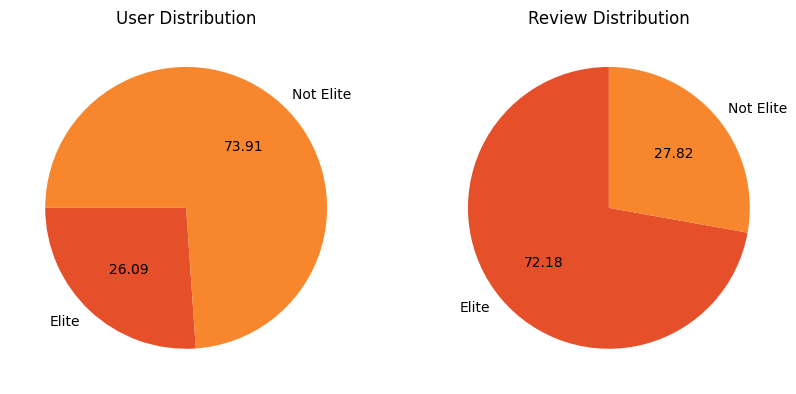

In [55]:
# ===================== ELITE VS NON-ELITE USER VISUALIZATION ===================== #
# Visualize user distribution and review contribution of elite users

plt.figure(figsize=(10,6))                           # Set overall figure size

# --------------------- USER DISTRIBUTION PIE CHART --------------------- #

plt.subplot(1,2,1)                                  # Create first subplot

plt.title('User Distribution')                      # Set chart title

plt.pie(
    
    elite_df['num_users'],                          # Number of users
    
    labels = elite_df['elite'],                    # Labels for categories
    
    autopct='%.2f',                                # Show percentage values
    
    startangle = 180,                              # Rotate pie chart
    
    colors = ['#E54F29','#F8862C']                 # Set custom colors
    
)

# --------------------- REVIEW DISTRIBUTION PIE CHART --------------------- #

plt.subplot(1,2,2)                                  # Create second subplot

plt.title('Review Distribution')                    # Set chart title

plt.pie(
    
    elite_df['total_review_count'],                # Total review counts
    
    labels = elite_df['elite'],                    # Labels for categories
    
    autopct='%.2f',                                # Show percentage values
    
    startangle = 90,                               # Rotate pie chart
    
    colors = ['#E54F29','#F8862C']                 # Set custom colors
    
)

plt.show()                                          # Display final visualization

In [56]:
# ===================== BUSIEST HOURS RESTAURANT ANALYSIS ===================== #
# Analyze customer engagement patterns across different hours of the day

# --------------------- REVIEW ENGAGEMENT ANALYSIS --------------------- #

review_engagement = pd.read_sql_query("""

SELECT

    CAST(strftime('%H', date) AS INTEGER) AS hour,   -- Extract hour from review timestamp

    COUNT(*) AS review_count                         -- Count total reviews per hour

FROM review

GROUP BY hour                                        -- Group data by hour

""", conn)

# --------------------- TIP ENGAGEMENT ANALYSIS --------------------- #

tip_engagement = pd.read_sql_query("""

SELECT

    CAST(strftime('%H', date) AS INTEGER) AS hour,   -- Extract hour from tip timestamp

    COUNT(*) AS tip_count                            -- Count total tips per hour

FROM tip

GROUP BY hour                                        -- Group data by hour

""", conn)

# --------------------- CHECK-IN ENGAGEMENT ANALYSIS --------------------- #

checkin = pd.read_sql_query(

    """SELECT date FROM checkin""", conn             # Fetch check-in timestamps

)

checkin_engagement = []                              # Create empty list for storing hours

for i in checkin['date']:                            # Loop through each check-in record

    checkin_engagement.extend(
        
        [
            datetime.strptime(
                
                j.strip(),                           # Remove extra spaces
                
                "%Y-%m-%d %H:%M:%S"                 # Define datetime format
                
            ).strftime("%H")                        # Extract hour only
            
            for j in i.split(',')                   # Split multiple timestamps
            
        ]
    )

# Convert extracted hours into dataframe and count hourly engagement

checkin_engagement = pd.DataFrame(checkin_engagement)\
                        .astype('int')\
                        .groupby([0])[[0]]\
                        .count()

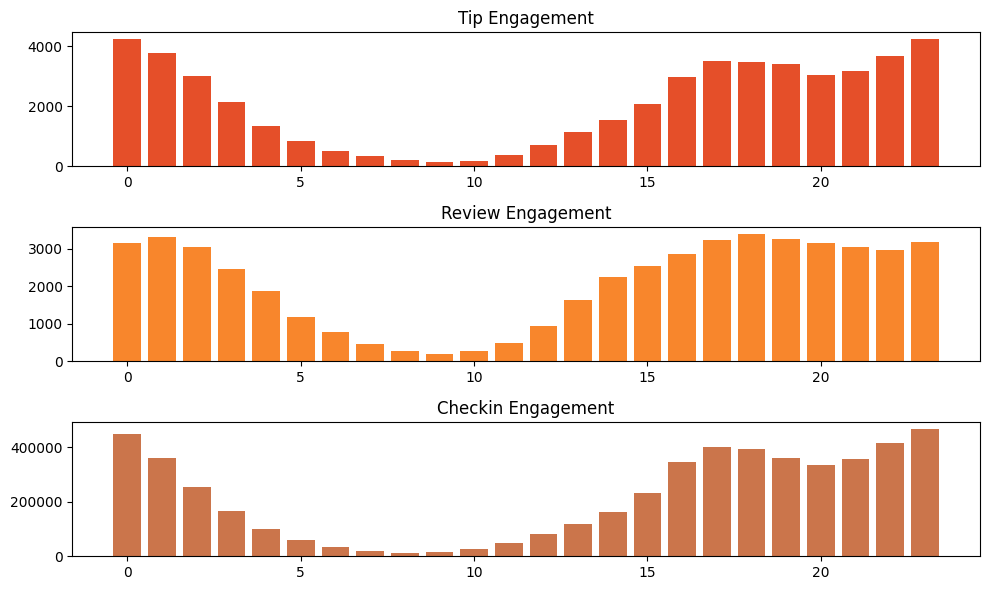

In [57]:
# ===================== BUSIEST HOURS VISUALIZATION ===================== #
# Visualize restaurant engagement patterns across different hours

plt.figure(figsize = (10,6))                         # Set overall figure size

# --------------------- TIP ENGAGEMENT BAR CHART --------------------- #

plt.subplot(3,1,1)                                  # Create first subplot

plt.title('Tip Engagement')                         # Set chart title

plt.bar(
    
    tip_engagement['hour'],                         # X-axis → Hours
    
    tip_engagement['tip_count'],                   # Y-axis → Tip counts
    
    color = '#E54F29'                              # Set bar color
    
)

# --------------------- REVIEW ENGAGEMENT BAR CHART --------------------- #

plt.subplot(3,1,2)                                  # Create second subplot

plt.title('Review Engagement')                      # Set chart title

plt.bar(
    
    review_engagement['hour'],                     # X-axis → Hours
    
    review_engagement['review_count'],             # Y-axis → Review counts
    
    color = '#F8862C'                              # Set bar color
    
)

# --------------------- CHECK-IN ENGAGEMENT BAR CHART --------------------- #

plt.subplot(3,1,3)                                  # Create third subplot

plt.title('Checkin Engagement')                    # Set chart title

plt.bar(
    
    checkin_engagement.index,                      # X-axis → Check-in hours
    
    checkin_engagement[0],                         # Y-axis → Check-in counts
    
    color = '#CB754B'                              # Set bar color
    
)

plt.tight_layout()                                 # Adjust subplot spacing automatically

plt.show()                                         # Display final visualization